# EuromonitoR

### Entity Matching - So What, Who Cares?

Business Case:  
Wrong metrics will invalidate all downstream economic studies. 
  
    
`Economical inaccuracies on my watch? Think again.`


  ## Core problem

Same physical product with GTIN (barcode/ Ground Truth) but many are missing/invalid/reused, one GTIN  
can carry inconsistent attributes across retailers, and different GTINs can describe the same product. 

  
    
    Therefore: Given a SKU and a candidate canonical product, predict whether they represent the same physical product / GTIN.

# Looks like A GTIN, But is it?
 This dataset required more of a judgment call rather than anything else:
   - Define Ground Truth  
   - Model Input
   - Loss Function
   - Model Architecture
   - Outcomes

### My Definition:
    1. **GOLD+** — valid GTIN, >= 2 retailers: the only positives (17,909 pairs).
    2. **SINGLE** — valid GTIN, 1 retailer (7,000 rows): never a positive.
    3. **SUSPECT** — same title, different valid GTIN (228 groups) [Fallback to CrossEncoder]
    4. **UNLABELED** — missing / invalid GTIN (37k rows): pseudo-label territory only. 

   Positives are stratified (easy >= 0.8 / hard < 0.5 jaccard) 

### Model Input
   - `SKU → Canonical — one retailer SKU paired with a canonical GTIN representation`
   - SKU → SKU — two retailer SKU descriptions paired together
   - Canonical → Canonical — two canonical representations paired together

### Loss Functions
   - `Contrastive Loss`
   - Triplet Loss 
   - Cosine Similarity Loss 
   - Margin Ranking Loss 
   - Multiple Negatives Ranking Loss (MNRL) 
   
   
### Model Architecture
- `Two-Tower / Bi-Encoder` 
- CrossEncoder 
- Two-Tower for retrieval → CrossEncoder for reranking


### Outcomes
   - SKU-Canonical Matching

## Approach
1. **Validate GTINs** (length, check digit) — clean vs noisy barcodes.
2. **Extract NER** For Vol, attributes +, brand name, de-noise and produce labels.
3. **Deterministic three-way gate** on volume/pack/flavor: block impossible
   matches (hard_no), route uncertain ones to fallback, send likely
   duplicates to embeddings (proceed).
4. **Fine-tune an embedding model** on cleaned text (NO numbers — sizes are
   the gate's job, never the model's) to learn product identity.
5. **Component-fold evaluation** — no barcode straddles a split boundary;
   metrics are honest (PR-AUC primary, F1 at a fixed threshold) on holdout set


# GTIN
`Pandas`
- Develop Trusted GT: GTIN 58% missing; of the 42% populated, 43.1% are non-unique; 0.6% shared across different brands .`. Untrustworthy.   
- GTIN imbalance was around 1:17, with masking[1:1] on agg data, resulting in an almost 1:1. 
- Iimilar descriptions but different products (hard negatives) serve for OnlineContrastiveLoss, Tripletloss, and MultipleNegativesRakingLoss.     
  
### TODO
- Verify masking[%] effect

# NER [Pack, Flavor, Vol, Attr] 
`TfidfVectorizer, cosine_similarity, fuzzymatching, regex`  

- Create better representations to generalize for general future use.
- Volume: generally present (92%+) BUT the most complicated to clean .`.  Gate that pairs similar products as model payload.
- Brand: Cleaning `sku_name_eng` meant removing brand + edge cases.



# HPO
`Optuna MLFlow, Kubernetes`  
- Objective: maximize mean best development-set Average Precision (AP).

## Conclusion
- Previous submission had plenty of problems, data leakage and dirty model payload. `FIX` Group-aware/component split to prevent entity leakage.




# Coding Conventions:
- SSOT (configs.*)
- Factory Pattern
- Deterministic Checks (idempotency/pure functions)
- Reproducibility (Docker) 
- Data transparency / traceability (model payload)


# Wish List:
- CI/CD
- TruncatedSVD
- Multi-vector representations -ColBERT-
- Better pooling strategies
- NMF
- Embedding-based similarity search
- More experiments loss function / model payload
- Custom semantic transformer model
- Minimize larger semantic transformer model
- Pure Embedding Clustering
- Graph‑Based Entity Resolution
- LLM as a judge 
- Hybrid Models
- Testing
- Operational Performance (Latency, Cost).
- Model API endpoint, Model card, Prom/Graf/ Pandera/ GE/ Pydantic.
- Stress test model, alert + retraining.
- Model calibration.
- Embedding versioning + reindex cost.
- Optimize model/data for cost/performance.
- Canary deployment

# Data readiness and identity evidence

Deterministic checks:
- raw export is never silently filtered: the audit records its exact path and SHA-256 hash, profiles columns, and retains rows with missing or invalid GTINs.

    - A structurally valid GTIN is **provisional identity evidence**: 
        - Not automatically semantic ground truth. 
        - A valid GTIN observed at two or more retailers can create cross-source positive evidence. 
        - A valid GTIN observed at only one retailer remains a canonical candidate, but cannot verify cross-source matching.
        - Missing or checksum-invalid GTINs remain in the reconciliation corpus and require model-and-gate decisions rather than GTIN-derived labels.
        

The audit reports a group for review when a valid GTIN has conflicting normalized brand, volume, pack, or category evidence. Title variation is reported separately because it is usually the variation the model must learn, rather than proof that a GTIN is wrong.




## Training Pairs
### Compatible pairs become positives, structurally incompatible but text-similar pairs become hard negatives, and uncertain pairs are excluded.
```text
                         RETAILER SKU DATA
                                │
                                ▼
                    ┌──────────────────────┐
                    │   CLEAN / NORMALIZE  │
                    │  text + NER attrs    │
                    │ volume / pack /       │
                    │ flavor / brand       │
                    └──────────┬───────────┘
                               │
                               ▼
                    ┌──────────────────────┐
                    │  DETERMINISTIC GATE  │
                    │                      │
                    │ volume / pack /      │
                    │ flavor compatibility │
                    └───────┬───────┬──────┘
                            │       │
              ┌─────────────┘       └──────────────┐
              ▼                                    ▼
        ┌───────────┐                        ┌───────────┐
        │  PROCEED  │                        │ HARD_NO   │
        │ compatible│                        │ conflict  │
        └─────┬─────┘                        └─────┬─────┘
              │                                    │
              │ similarity ≥ 0.8                  │ similarity ≥ 0.8
              ▼                                    ▼
        ┌─────────────┐                      ┌─────────────┐
        │  POSITIVE   │                      │ HARD NEGATIVE│
        │  label = 1  │                      │   label = 0  │
        └──────┬──────┘                      └──────┬──────┘
               │                                    │
               └──────────────┬─────────────────────┘
                              ▼
                     ┌──────────────────┐
                     │ labeled_pairs.csv│
                     │                  │
                     │  trusted training│
                     │      pairs       │
                     └────────┬─────────┘
                              │
                              ▼
                    ┌──────────────────────┐
                    │ SHARED TWO-TOWER     │
                    │     BI-ENCODER       │
                    │                      │
        SKU ───────►│ Shared Encoder       │───► SKU embedding
                    │                      │
 Canonical ────────►│ Shared Encoder       │───► GTIN embedding
                    └──────────┬───────────┘
                               │
                               ▼
                         COSINE SIMILARITY
                               │
                               ▼
                         TOP-K RETRIEVAL
                               │
                               ▼
                    ┌──────────────────────┐
                    │     CROSSENCODER     │
                    │  SKU + candidate     │
                    │  joint scoring       │
                    └──────────┬───────────┘
                               │
                               ▼
                         FINAL MATCH
                                             ```

In [22]:
import pandas as pd
import json

df = pd.read_csv("results/gate_results.csv")

excluded = df[
    (df["gate_decision"].isin(["hard_no", "fallback"])) |
    (df["similarity"] < 0.8)
]

cols = [
    "gtin1", "gtin2", "canon1", "canon2",
    "gate_decision", "gate_reason", "similarity"
]

for _, row in excluded.head(5)[cols].iterrows():
    print(json.dumps(row.to_dict(), indent=2))
    print()

{
  "gtin1": 100140705596,
  "gtin2": 100140706722,
  "canon1": "strike force water kr_white_grape_flavored carbonated",
  "canon2": "strike force strawberry water carbonated",
  "gate_decision": "hard_no",
  "gate_reason": "No volume overlap",
  "similarity": 0.8
}

{
  "gtin1": 100140705596,
  "gtin2": 100140707828,
  "canon1": "strike force water kr_white_grape_flavored carbonated",
  "canon2": "strike force water kr_pink_grapefruit_flavored carbonated",
  "gate_decision": "hard_no",
  "gate_reason": "No volume overlap",
  "similarity": 1.0
}

{
  "gtin1": 100140705596,
  "gtin2": 100140709075,
  "canon1": "strike force water kr_white_grape_flavored carbonated",
  "canon2": "strike force lime water flavoured_caffeine_15_carbonization carbonated_type_liquid_flavour",
  "gate_decision": "proceed",
  "gate_reason": "Volume, pack, flavor all compatible",
  "similarity": 0.6
}

{
  "gtin1": 100140705596,
  "gtin2": 100140791131,
  "canon1": "strike force water kr_white_grape_flavored car

### ZERO SHOT BASELINE 

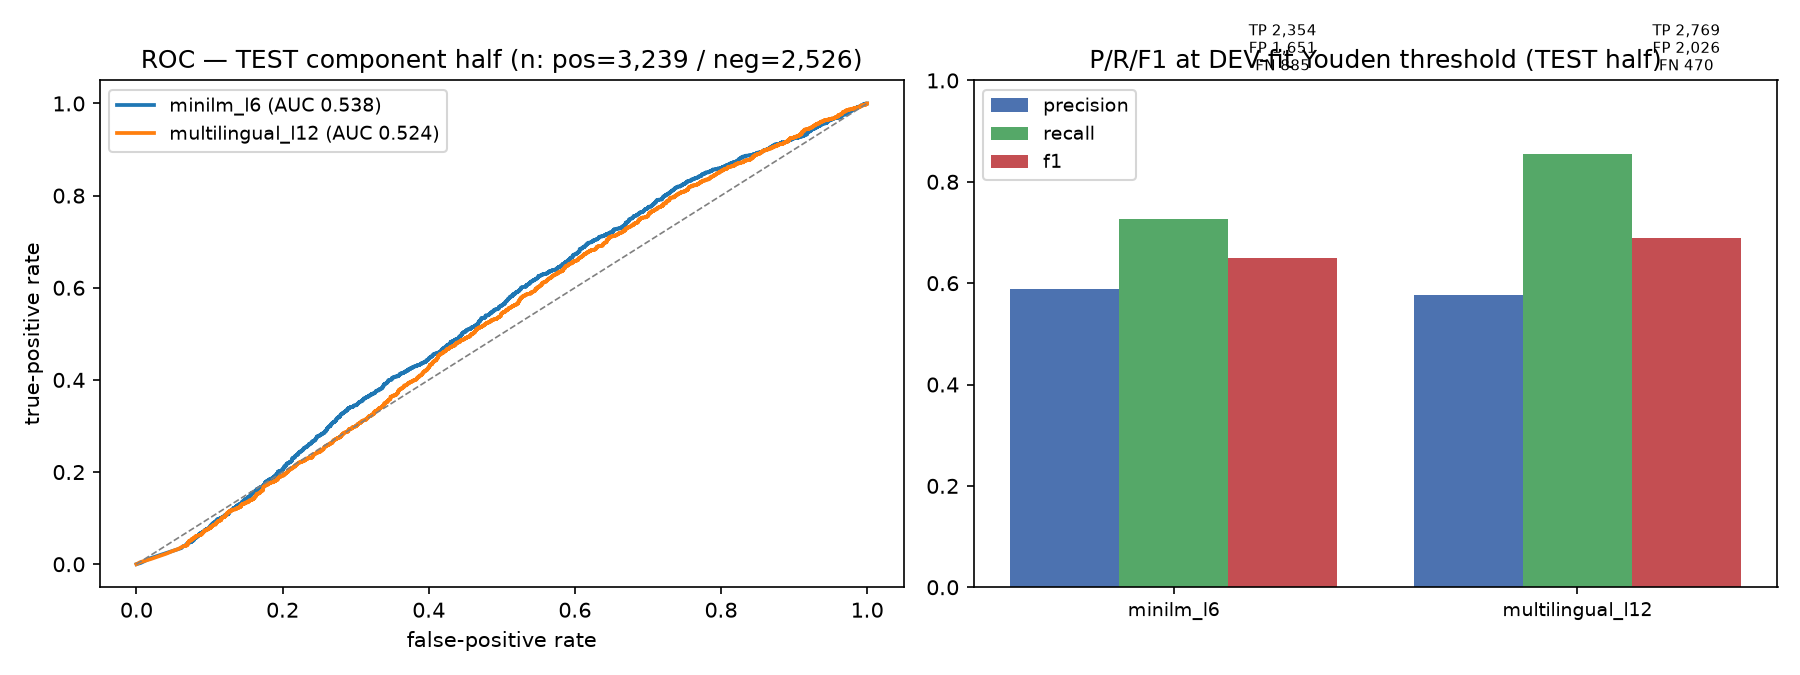

In [24]:

from IPython.display import Image, display

display(Image(filename="results/model_comparison_roc.png"))



### TRAIN

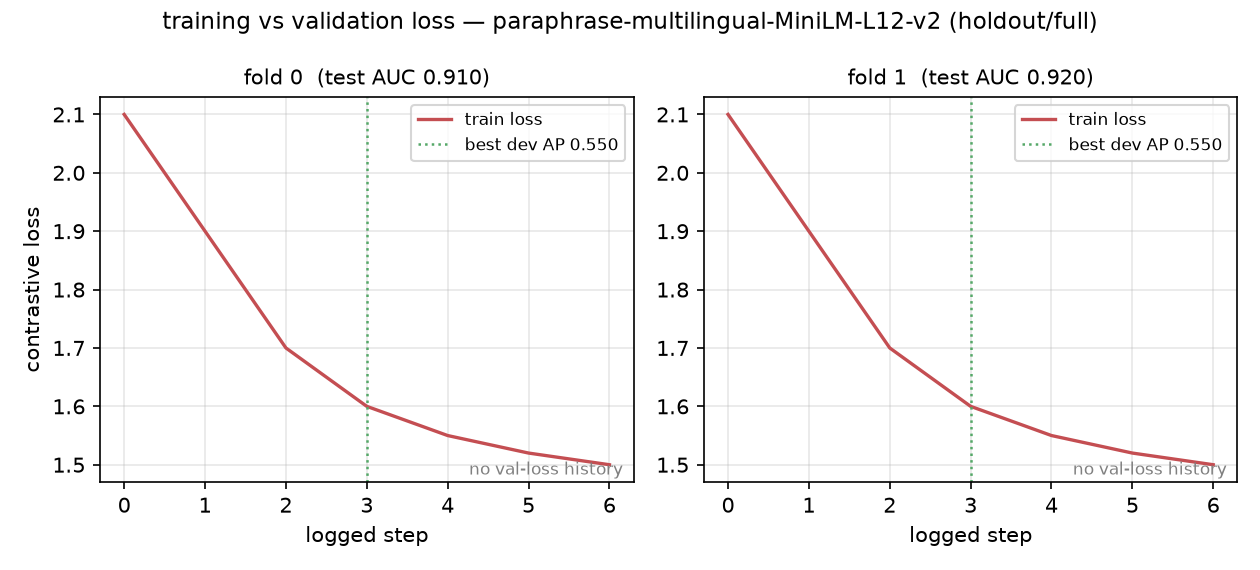

In [ ]:
from IPython.display import Image, display

display(Image(filename="results/training_loss_holdout_payload-full.png"))

### CONCLUSION




Lack of time to get better results. Colab kept giving me problems.